## ***Initials***

In [2]:
!pip install geopandas pandas shapely

   ---------------------------------------- 0.0/323.6 kB ? eta -:--:--
   --- ------------------------------------ 30.7/323.6 kB 1.4 MB/s eta 0:00:01
   ------- ------------------------------- 61.4/323.6 kB 825.8 kB/s eta 0:00:01
   --------------- ------------------------ 122.9/323.6 kB 1.0 MB/s eta 0:00:01
   ------------------------ --------------- 194.6/323.6 kB 1.2 MB/s eta 0:00:01
   -------------------------------- ------- 266.2/323.6 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 323.6/323.6 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------ --------------------------------- 0.2/1.4 MB 7.3 MB/s eta 0:00:01
   -------- ------------------------------- 0.3/1.4 MB 3.9 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.4 MB 4.0 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.4 MB 3.9 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.4 MB 3.9 MB/s eta 0:00:01
 

In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# ***Add the Feature: 'Municipal Community' on each Business Entry***

## ***Load the Data***

In [19]:
# --- 1. Load the business CSV ---
business_df = pd.read_csv("Merged Data/cleaned-forsquare_xrysosOdigos_greekCatalog_vacationRenter.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Merged Data/cleaned-forsquare_xrysosOdigos_greekCatalog_vacationRenter.csv'

In [13]:
business_df.head()

,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN),geometry
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili...",POINT (22.923506 39.335293)
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a...",POINT (22.923969 39.339233)
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations,POINT (22.926496 39.332305)
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road,POINT (22.929457 39.332756)
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,POINT (22.929374 39.332876)


In [5]:
# --- 2. Convert to GeoDataFrame ---
business_df['geometry'] = business_df.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)

In [7]:
business_gdf = gpd.GeoDataFrame(business_df, geometry='geometry', crs="EPSG:4326")

In [9]:
# --- 3. Load the polygon layer (the exported shapefile from QGIS) ---
admin_gdf = gpd.read_file("ELSTAT/ΔΗΜΟΤΙΚΕΣ ΚΟΙΝΟΤΗΤΕΣ/LAU2021.shp")

In [10]:
admin_gdf = admin_gdf.to_crs("EPSG:4326")

## ***Perfrom the Spatial Join to get the Municipal Community of the Entry***

In [11]:
# --- 4. Spatial join ---
joined = gpd.sjoin(business_gdf, admin_gdf, how="left", predicate="intersects")

In [14]:
columns_to_drop = ['geometry', 'index_right', 'KAL2022', 'Shape_Leng', 'Shape_Le_1', 'Shape_Area']
joined.drop(columns=columns_to_drop, inplace=True)

In [16]:
joined.rename(columns={"LAU_LABEL3": "Municipal_Community"}, inplace=True)

In [17]:
joined.head()

,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN),Municipal_Community
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili...",Δημοτική Κοινότητα Βόλου
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a...",Δημοτική Κοινότητα Βόλου
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations,Δημοτική Κοινότητα Βόλου
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road,Δημοτική Κοινότητα Βόλου
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,Δημοτική Κοινότητα Βόλου


## ***Save the Data***

In [18]:
joined.to_csv("cleaned_businesses_with_community.csv", index=False)

## ***Sanity Checks***

In [2]:
joined = pd.read_csv("Merged Data/business_data.csv")

Municipal_Community
Δημοτική Κοινότητα Βόλου                     3080
Δημοτική Κοινότητα Νέας Ιωνίας                495
Δημοτική Κοινότητα Νέας Αγχιάλου              112
Δημοτική Κοινότητα Αγριάς                      81
Δημοτική Κοινότητα Διμηνίου                    40
Δημοτική Κοινότητα Ανακασιάς                   24
Δημοτική Κοινότητα Μικροθηβών                   8
Δημοτική Κοινότητα Σέσκλου                      8
Δημοτική Κοινότητα Άνω Βόλου                    7
Δημοτική Κοινότητα Άλλης Μεριάς                 7
Δημοτική Κοινότητα Μακρινίτσης                  4
Δημοτική Κοινότητα Πορταριάς                    4
Δημοτική Κοινότητα Κάτω Λεχωνίων                4
Δημοτική Κοινότητα Αλμυρού                      3
Δημοτική Κοινότητα Αγίου Γεωργίου Νηλείας       3
Δημοτική Κοινότητα Αγίου Γεωργίου Φερών         2
Δημοτική Κοινότητα Δρακείας                     2
Δημοτική Κοινότητα Άνω Λεχωνίων                 2
Δημοτική Κοινότητα Αγίου Ονουφρίου              2
Δημοτική Κοινότητα Ζαγοράς    

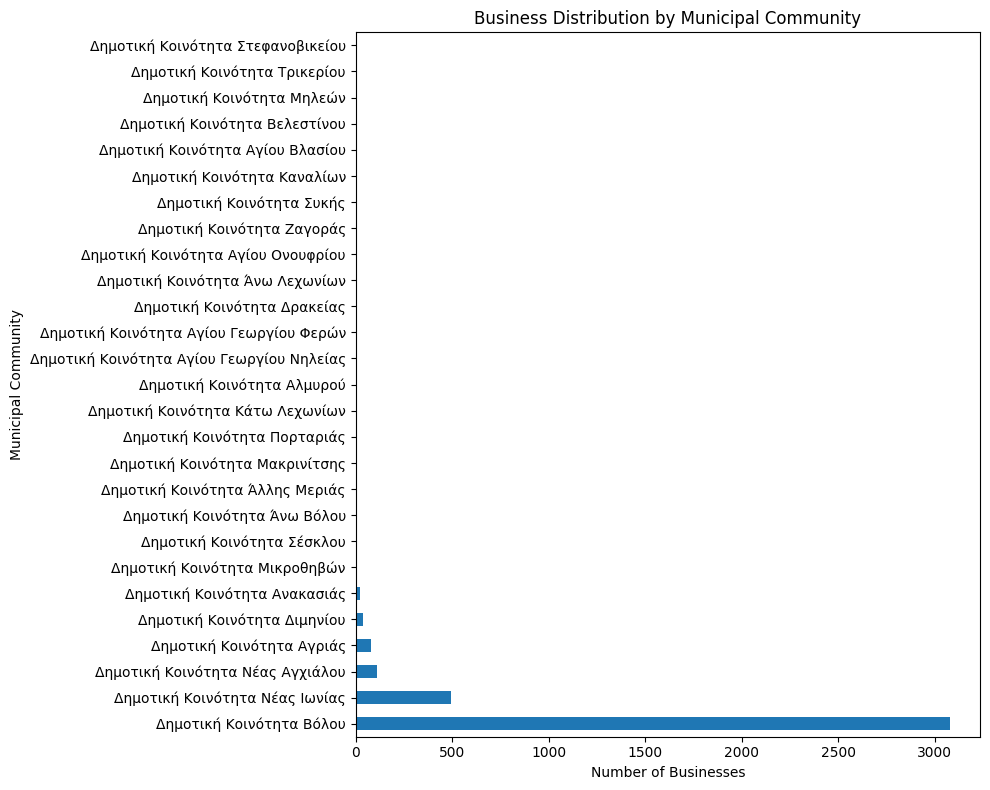

In [3]:
joined['Municipal_Community'].value_counts()
print(joined['Municipal_Community'].value_counts())


import matplotlib.pyplot as plt

joined['Municipal_Community'].value_counts().plot(kind='barh', figsize=(10, 8))
plt.xlabel("Number of Businesses")
plt.ylabel("Municipal Community")
plt.title("Business Distribution by Municipal Community")
plt.tight_layout()
plt.show()


In [22]:
# check if the municipal communitites are valid
elstat_df = pd.read_csv("C:/Users/Giorgos/Desktop/HMMY/10ο Εξάμηνο/Διπλωματική/Datasets/ELSTAT/Στατιστικές/Πληθυσμός και Κοινωνικές Συνθήκες/ELSTAT-demographic-economic.csv")

In [5]:
communities_in_joined = set(joined['Municipal_Community'].dropna().unique())
communities_in_elstat = set(elstat_df['ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ'].dropna().unique())

In [6]:
missing_communities = communities_in_joined - communities_in_elstat
print("Communities found in joined data but missing in ELSTAT dataset:")
print(missing_communities)


Communities found in joined data but missing in ELSTAT dataset:
set()


In [ ]:
unused_communities = communities_in_elstat - communities_in_joined
print("Communities in ELSTAT that have no businesses assigned:")
print(unused_communities)

Communities in ELSTAT that have no businesses assigned:
{'Δημοτική Κοινότητα Πρόπαν', 'Δημοτική Κοινότητα Γλαφυρών', 'Δημοτική Κοινότητα Βυζίτσης', 'Δημοτική Κοινότητα Κωφών', 'Δημοτική Κοινότητα Ξινόβρυσης', 'Δημοτική Κοινότητα Μηλίνης', 'Δημοτική Κοινότητα Κεραμιδίου', 'Δημοτική Κοινότητα Αργαλαστής', 'Δημοτική Κοινότητα Ανηλίου', 'Δημοτική Κοινότητα Πουρίου', 'Δημοτική Κοινότητα Νεοχωρίου', 'Δημοτική Κοινότητα Πτελεού', 'Δημοτική Κοινότητα Ριζομύλου', 'Δημοτική Κοινότητα Ανθοτόπου', 'Δημοτική Κοινότητα Δρυμώνος', 'Δημοτική Κοινότητα Κοκκωτών', 'Δημοτική Κοινότητα Μετοχίου', 'Δημοτική Κοινότητα Αγίου Δημητρίου Πηλίου', 'Δημοτική Κοινότητα Σούρπης', 'Δημοτική Κοινότητα Βρυναίνης', 'Δημοτική Κοινότητα Αγίου Λαυρεντίου', 'Δημοτική Κοινότητα Αμαλιαπόλεως', 'Δημοτική Κοινότητα Ξορυχτίου', 'Δημοτική Κοινότητα Αϊδινίου', 'Δημοτική Κοινότητα Μικρού Περιβολακίου', 'Δημοτική Κοινότητα Τσαγκαράδας', 'Δημοτική Κοινότητα Μουρεσίου', 'Δημοτική Κοινότητα Κροκίου', 'Δημοτική Κοινότητα Προμυρίου', 'Δ

As we see, all the municipal communities of my dataset are valid, meaning that they exist in the mapping file "ELSTAT-demographic-economic.csv" as rows
-> Win !!

# ***Join: the Business Data with Economic/Demographic Data***

We will perform a ***spatial join*** based on the ***municipal cimmunity*** for the 2 datasets, in order to get the full dataset!

## ***Load the Data***

In [2]:
# --- 1. Load the business CSV ---
business_df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\2. Joining - Business - Municipal Community Data\\Exrtacted CSV Files\\business_data.csv")

In [3]:
print(len(business_df))
print(business_df.shape)
business_df.head()

3906
(3906, 15)


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN),Municipal_Community
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili...",Municipal Community of Volos
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a...",Municipal Community of Volos
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations,Municipal Community of Volos
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road,Municipal Community of Volos
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,Municipal Community of Volos


In [4]:
# check if the municipal communitites are valid
elstat_df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\2. Data - Municipal Communities\\4. Exploratory Data Analysis\\Extracted CSV Files\\ELSTAT-demographic-economic.csv")

In [5]:
print(len(elstat_df))
print(elstat_df.shape)
elstat_df.head()

76
(76, 23)


,Unnamed: 0,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΣ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ ΕΛΛ,ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ,Population,Άγαμοι_pct,Έγγαμοι_pct,Χήροι_pct,...,age_65_plus_pct,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2
0,0,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,Δημοτική Κοινότητα Βόλου,Municipal Community of Volos,85806,0.4032,0.4630,0.0809,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
1,1,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Αγριάς,Municipal Community of Agria,4926,0.3577,0.5173,0.0796,...,0.2359,0.4670,0.3341,0.1987,0.1555,0.3955,0.0816,0.1864,0.7314,3.737347
2,2,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Δρακείας,Municipal Community of Drakeia,369,0.3496,0.4580,0.1382,...,0.2873,0.6667,0.2493,0.0840,0.1439,0.3767,0.4545,0.0826,0.4628,21.683415
3,3,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Διμηνίου,Municipal Community of Dimini,2101,0.3889,0.5007,0.0776,...,0.2080,0.5437,0.3163,0.1395,0.2211,0.4327,0.1161,0.2365,0.6459,37.323451
4,4,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Σέσκλου,Municipal Community of Sesklos,899,0.3960,0.5184,0.0645,...,0.2147,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725


In [6]:
# Rename the key column in the municipal data for consistency if needed
elstat_df.rename(columns={
    'ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ': 'Municipal_Community'
}, inplace=True)


## ***Merge the data by Joining on the Feature 'municipal_community'***

In [16]:
# Perform the join on the Municipal Community column
merged_df = pd.merge(business_df, elstat_df, on="Municipal_Community", how="left")

In [18]:
merged_df = merged_df.drop(['Unnamed: 0', 'ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ ΕΛΛ'], axis=1)

In [19]:
merged_df['Municipal_Community']

0       Municipal Community of Volos
1       Municipal Community of Volos
2       Municipal Community of Volos
3       Municipal Community of Volos
4       Municipal Community of Volos
                    ...             
3901    Municipal Community of Volos
3902    Municipal Community of Volos
3903    Municipal Community of Volos
3904    Municipal Community of Volos
3905    Municipal Community of Volos
Name: Municipal_Community, Length: 3906, dtype: object

In [20]:
print(len(merged_df))
print(merged_df.shape)
print(merged_df.columns)
merged_df.head()

3906
(3906, 35)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ', 'Population',
       'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct', 'Διαζευγμένοι_pct',
       'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct', 'low_education_pct',
       'medium_education_pct', 'high_education_pct', 'unemployment_rate',
       'labor_force_participation_rate', 'primary_sector_pct',
       'secondary_sector_pct', 'tertiary_sector_pct', 'Area_km2'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,...,age_65_plus_pct,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807


## ***Save the Merged Data***

In [21]:
merged_df.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\2. Joining - Business - Municipal Community Data\\Exrtacted CSV Files\\business_data_economic_demographic.csv", index=False)

In [22]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3906 entries, 0 to 3905
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Name                            3906 non-null   object 
 1   Category                        3906 non-null   object 
 2   Latitude                        3906 non-null   float64
 3   Longitude                       3906 non-null   float64
 4   Address                         3906 non-null   object 
 5   Country                         3906 non-null   object 
 6   City                            3906 non-null   object 
 7   Postal Code                     3906 non-null   int64  
 8   Rating                          232 non-null    float64
 9   Reviews                         213 non-null    float64
 10  Source                          3906 non-null   object 
 11  Description                     191 non-null    object 
 12  NACE Code                       39

In [23]:
merged_df.isnull().sum()

Name                                 0
Category                             0
Latitude                             0
Longitude                            0
Address                              0
Country                              0
City                                 0
Postal Code                          0
Rating                            3674
Reviews                           3693
Source                               0
Description                       3715
NACE Code                            0
NACE Description (EN)                0
Municipal_Community                  0
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ                 0
ΔΗΜΟΣ                                0
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ                     0
Population                           0
Άγαμοι_pct                           0
Έγγαμοι_pct                          0
Χήροι_pct                            0
Διαζευγμένοι_pct                     0
age_0_14_pct                         0
age_15_64_pct                        0
age_65_plus_pct          

## ***Sanity Checks***

In [24]:
df_saved = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\2. Joining - Business - Municipal Community Data\\Exrtacted CSV Files\\business_data_economic_demographic.csv")

In [25]:
print(df_saved.shape)
print(df_saved.columns)
df_saved.head()

(3906, 35)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ', 'Population',
       'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct', 'Διαζευγμένοι_pct',
       'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct', 'low_education_pct',
       'medium_education_pct', 'high_education_pct', 'unemployment_rate',
       'labor_force_participation_rate', 'primary_sector_pct',
       'secondary_sector_pct', 'tertiary_sector_pct', 'Area_km2'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,...,age_65_plus_pct,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
